# Data Cleaning and Preprocessing

Before building machine learning models, the dataset must be cleaned and prepared. This section includes handling missing values, removing duplicates, correcting data types, feature engineering, outlier treatment, and encoding categorical variables.

Proper preprocessing improves data quality and helps machine learning models achieve better performance.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df_dataset = pd.read_csv("AB_NYC_2019.csv")

## Initial Dataset Inspection

The first step is to examine the structure of the dataset, identify missing values, and understand the types of variables available for analysis.

In [31]:
df_dataset.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [32]:
df_dataset.shape

(48895, 16)

In [33]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [34]:
df_dataset.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [35]:
df_dataset.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## Missing Value Handling

Missing values were identified in several variables such as `name`, `host_name`, `last_review`, and `reviews_per_month`.



Missing values in `reviews_per_month` were replaced with 0, assuming that listings without reviews have no monthly review activity.

In [36]:


df_dataset['reviews_per_month'] = (
    df_dataset['reviews_per_month'].fillna(0)
)

In [37]:
df_dataset.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## Duplicate Removal

Duplicate observations were removed to improve data quality and avoid bias during model training.

In [38]:
df_dataset = df_dataset.drop_duplicates()

In [39]:
df_dataset.shape

(48895, 16)

## Datetime Conversion and Feature Engineering

The `last_review` column was converted into datetime format. Additional features such as review year and review month were extracted to preserve potentially useful temporal information for later analysis and modeling.

In [40]:
df_dataset['last_review'] = pd.to_datetime(
    df_dataset['last_review']
)

In [41]:
df_dataset['last_review_year'] = (
    df_dataset['last_review'].dt.year
)

df_dataset['last_review_month'] = (
    df_dataset['last_review'].dt.month
)

In [42]:
df_dataset['last_review_year'] = (
    df_dataset['last_review_year'].fillna(0)
)

df_dataset['last_review_month'] = (
    df_dataset['last_review_month'].fillna(0)
)

In [55]:
df_dataset['last_review_year'] = (
    df_dataset['last_review_year'].astype(int)
)

df_dataset['last_review_month'] = (
    df_dataset['last_review_month'].astype(int)
)

In [43]:
df_dataset = df_dataset.drop(columns=['last_review'])

## Removing Unnecessary Columns

Identifier columns such as `id` and `host_id` do not provide predictive value for the regression task and were removed.

Text-based columns such as `name` and `host_name` were also removed to reduce noise and simplify the modeling process.

In [44]:
df_dataset = df_dataset.drop(
    columns=['id', 'host_id', 'name', 'host_name','neighbourhood']
)

## Removing Invalid Target Values

Listings with a price equal to 0 were removed because they do not represent realistic Airbnb rental prices.

In [45]:
df_dataset = df_dataset[df_dataset['price'] > 0]

## Outlier Treatment

Extreme outliers in the target variable (`price`) were treated using the Interquartile Range (IQR) method.

Observations outside the acceptable range were removed to reduce the influence of extreme values on model performance.

In [46]:
Q1 = df_dataset['price'].quantile(0.25)
Q3 = df_dataset['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

df_dataset = df_dataset[
    (df_dataset['price'] >= lower_bound) &
    (df_dataset['price'] <= upper_bound)
]

## Target Variable Transformation

The `price` variable exhibited a right-skewed distribution. A logarithmic transformation using `log1p()` was applied to reduce skewness and improve regression model stability.

In [47]:
df_dataset['price'] = np.log1p(df_dataset['price'])

## Additional Feature Engineering

Additional binary features were created to capture listing behavior and availability patterns.

In [48]:
df_dataset['is_highly_available'] = (
    df_dataset['availability_365'] > 180
).astype(int)

df_dataset['has_many_reviews'] = (
    df_dataset['number_of_reviews'] > 50
).astype(int)

## Encoding Categorical Variables

Categorical variables were transformed using One-Hot Encoding to prepare the dataset for machine learning algorithms.

In [49]:
df_dataset = pd.get_dummies(
    df_dataset,
    columns=['neighbourhood_group', 'room_type'],
    drop_first=True
)

In [50]:
df_dataset = df_dataset.astype({
    col: 'int'
    for col in df_dataset.select_dtypes('bool').columns
})

## Final Dataset Inspection

The final dataset was inspected to confirm that preprocessing was successfully completed and the data was ready for exploratory analysis and modeling.

In [56]:
df_dataset.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,is_highly_available,has_many_reviews,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,5.010635,1,9,0.21,6,365,2018,10,1,0,1,0,0,0,1,0
1,40.75362,-73.98377,5.420535,1,45,0.38,2,355,2019,5,1,0,0,1,0,0,0,0
2,40.80902,-73.94190,5.017280,3,0,0.00,1,365,0,0,1,0,0,1,0,0,1,0
3,40.68514,-73.95976,4.499810,1,270,4.64,1,194,2019,7,1,1,1,0,0,0,0,0
4,40.79851,-73.94399,4.394449,10,9,0.10,1,0,2018,11,0,0,0,1,0,0,0,0


In [52]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45912 entries, 0 to 48894
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   latitude                           45912 non-null  float64
 1   longitude                          45912 non-null  float64
 2   price                              45912 non-null  float64
 3   minimum_nights                     45912 non-null  int64  
 4   number_of_reviews                  45912 non-null  int64  
 5   reviews_per_month                  45912 non-null  float64
 6   calculated_host_listings_count     45912 non-null  int64  
 7   availability_365                   45912 non-null  int64  
 8   last_review_year                   45912 non-null  float64
 9   last_review_month                  45912 non-null  float64
 10  is_highly_available                45912 non-null  int64  
 11  has_many_reviews                   45912 non-null  int64  


In [53]:
df_dataset.shape

(45912, 18)

In [54]:
df_dataset.isnull().sum()

latitude                             0
longitude                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
last_review_year                     0
last_review_month                    0
is_highly_available                  0
has_many_reviews                     0
neighbourhood_group_Brooklyn         0
neighbourhood_group_Manhattan        0
neighbourhood_group_Queens           0
neighbourhood_group_Staten Island    0
room_type_Private room               0
room_type_Shared room                0
dtype: int64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis was conducted to better understand the dataset, identify relationships between variables, and detect important patterns that may influence Airbnb listing prices.

The analysis includes graphical visualizations, descriptive statistics, and correlation analysis.

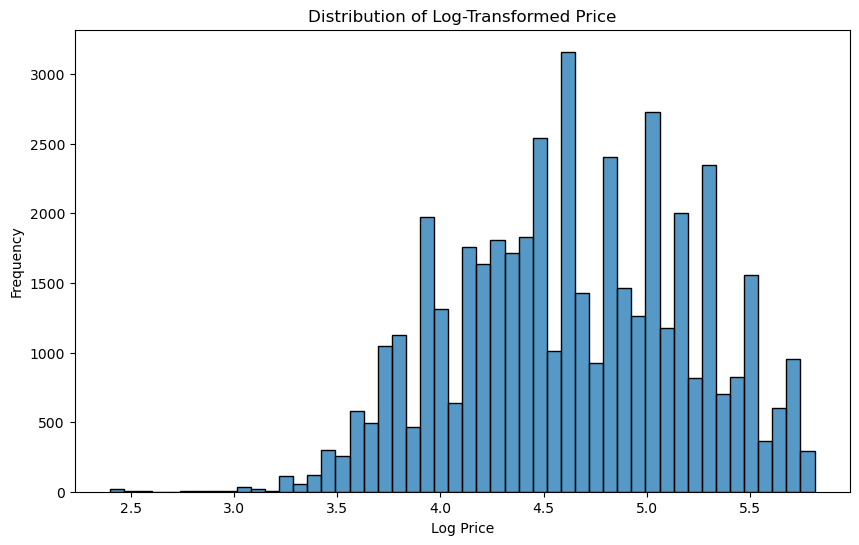

In [62]:
plt.figure(figsize=(10,6))

sns.histplot(df_dataset['price'], bins=50)

plt.title('Distribution of Log-Transformed Price')
plt.xlabel('Log Price')
plt.ylabel('Frequency')

plt.show()

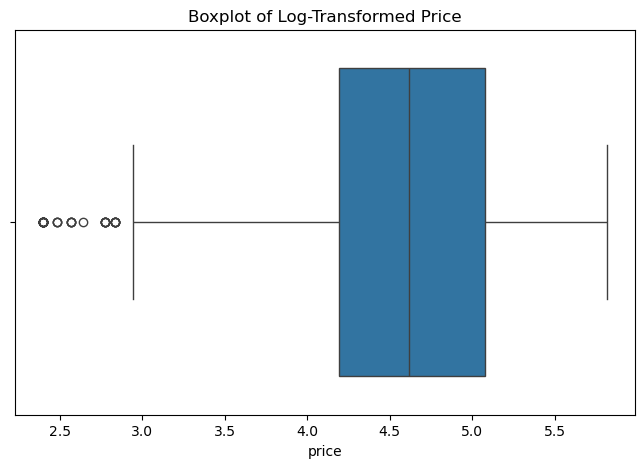

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_dataset['price'])

plt.title('Boxplot of Log-Transformed Price')

plt.show()

The boxplot shows that the logarithmic transformation successfully reduced the skewness of the `price` variable and compressed extreme values. Although a few mild outliers remain, the overall distribution appears significantly more stable and suitable for regression modeling.

## Relationship Between Room Type and Price

The relationship between room type and listing price was analyzed to determine whether different accommodation types influence Airbnb prices.

In [64]:
df_plot = df_dataset.copy()

df_plot['room_type'] = 'Entire home/apt'

df_plot.loc[
    df_plot['room_type_Private room'] == 1,
    'room_type'
] = 'Private room'

df_plot.loc[
    df_plot['room_type_Shared room'] == 1,
    'room_type'
] = 'Shared room'

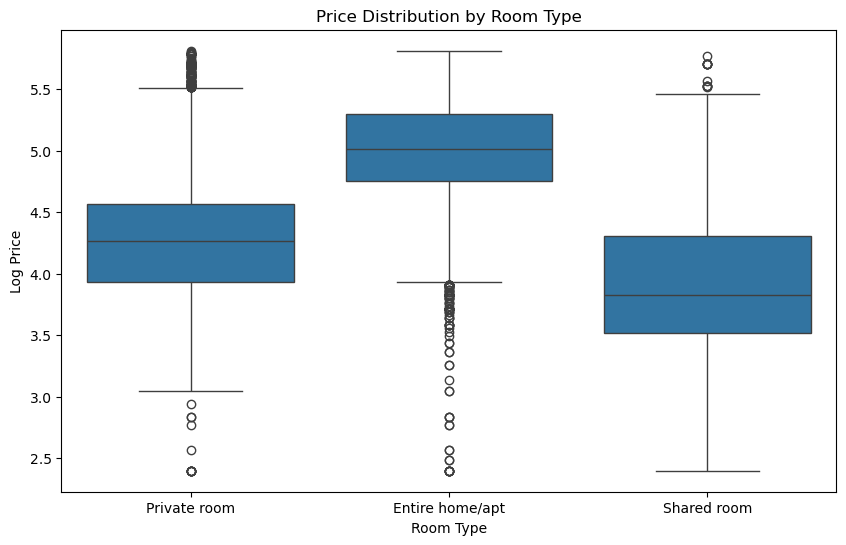

In [65]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_plot,
    x='room_type',
    y='price'
)

plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Log Price')

plt.show()

The boxplot demonstrates a clear relationship between room type and Airbnb listing prices. Entire homes/apartments exhibit the highest median prices, while shared rooms are generally the least expensive option. Private rooms occupy a middle position between the two categories.

The results suggest that room type is likely to be an important predictor in the regression modeling process.

In [66]:
df_plot['neighbourhood_group'] = 'Bronx'

df_plot.loc[
    df_plot['neighbourhood_group_Brooklyn'] == 1,
    'neighbourhood_group'
] = 'Brooklyn'

df_plot.loc[
    df_plot['neighbourhood_group_Manhattan'] == 1,
    'neighbourhood_group'
] = 'Manhattan'

df_plot.loc[
    df_plot['neighbourhood_group_Queens'] == 1,
    'neighbourhood_group'
] = 'Queens'

df_plot.loc[
    df_plot['neighbourhood_group_Staten Island'] == 1,
    'neighbourhood_group'
] = 'Staten Island'

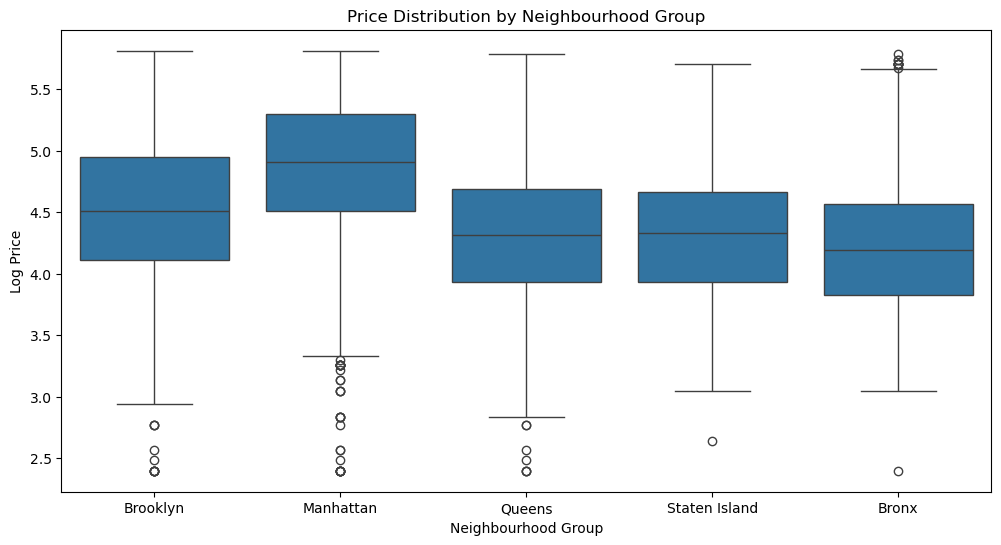

In [67]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_plot,
    x='neighbourhood_group',
    y='price'
)

plt.title('Price Distribution by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Log Price')

plt.show()

The boxplot reveals clear geographical differences in Airbnb listing prices across New York City boroughs. Manhattan exhibits the highest median prices, followed by Brooklyn, while Queens, Bronx, and Staten Island generally display lower price distributions.

These results suggest that location plays a significant role in determining Airbnb prices and is likely to be an important predictor in the regression models.

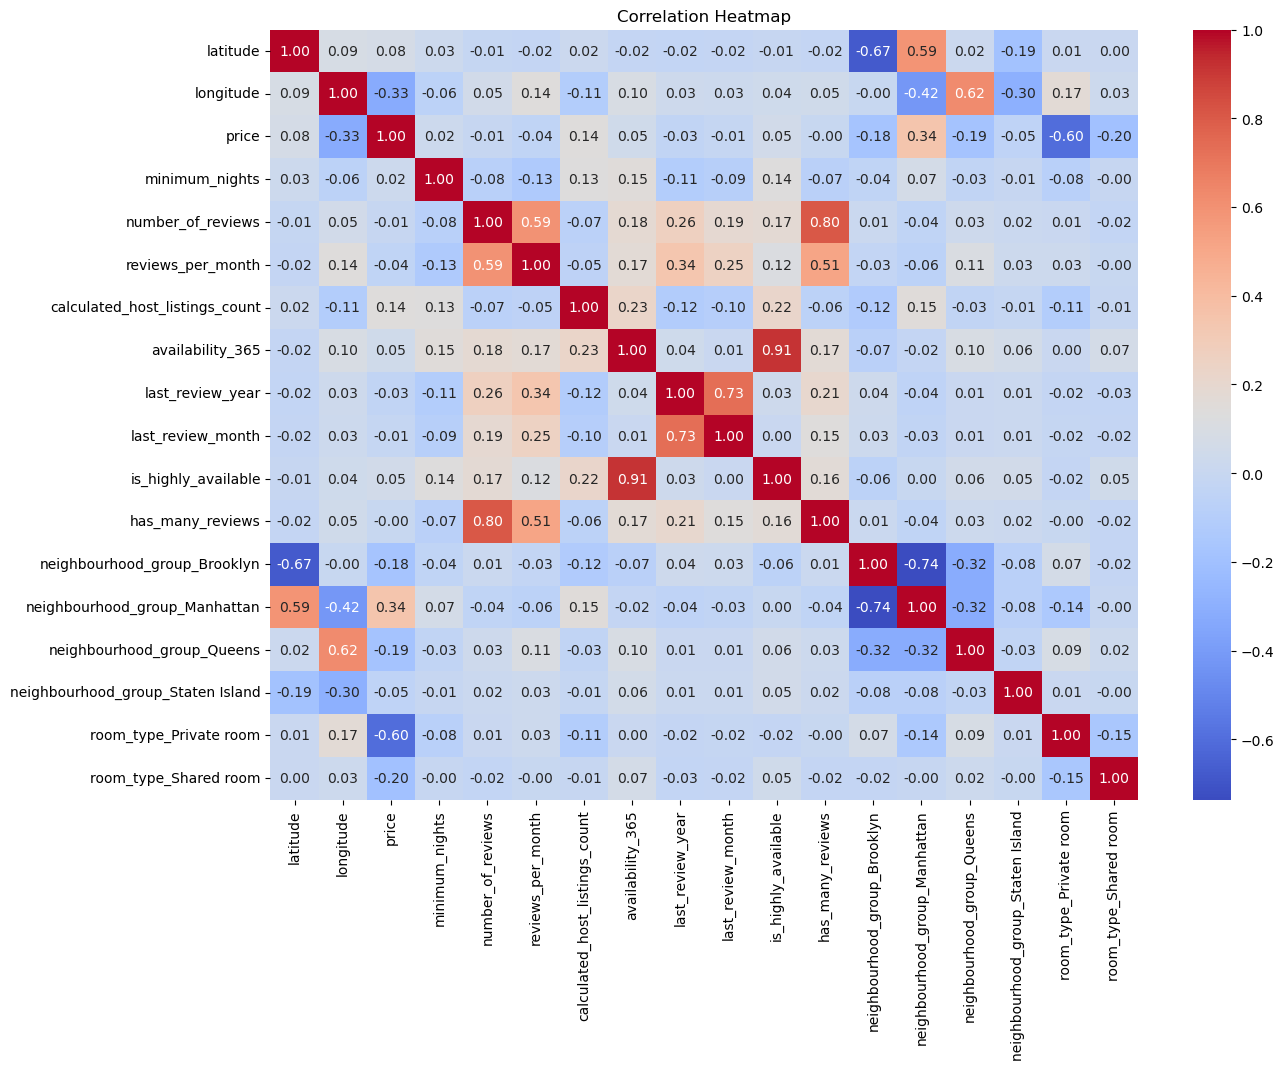

In [68]:
plt.figure(figsize=(14,10))

correlation_matrix = df_dataset.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title('Correlation Heatmap')

plt.show()

In [92]:
cluster_features = df_dataset[
    [
        'latitude',
        'longitude',
        'price'
    ]
]

## Clustering and Segmentation

KMeans clustering was applied to segment Airbnb listings into groups based on pricing, availability, popularity, and host activity characteristics.

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_features)

In [94]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 11)

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(scaled_features)
    
    inertia.append(kmeans.inertia_)

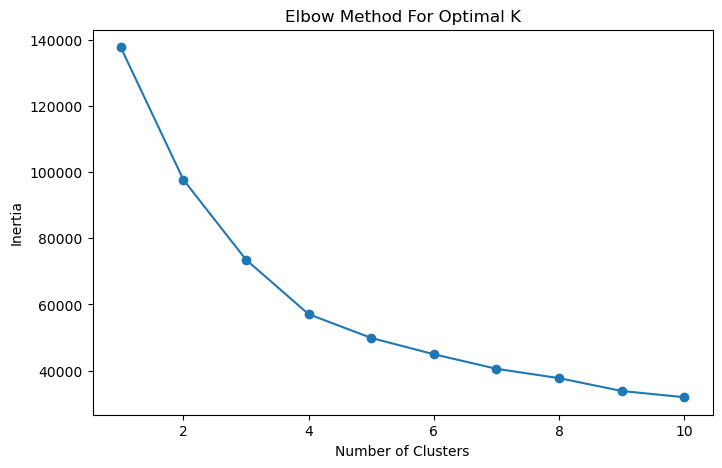

In [95]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

In [96]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df_dataset['Cluster'] = kmeans.fit_predict(
    scaled_features
)

In [97]:
df_dataset['Cluster'].value_counts()

Cluster
2    13007
0    11547
4     9927
3     9022
1     2409
Name: count, dtype: int64

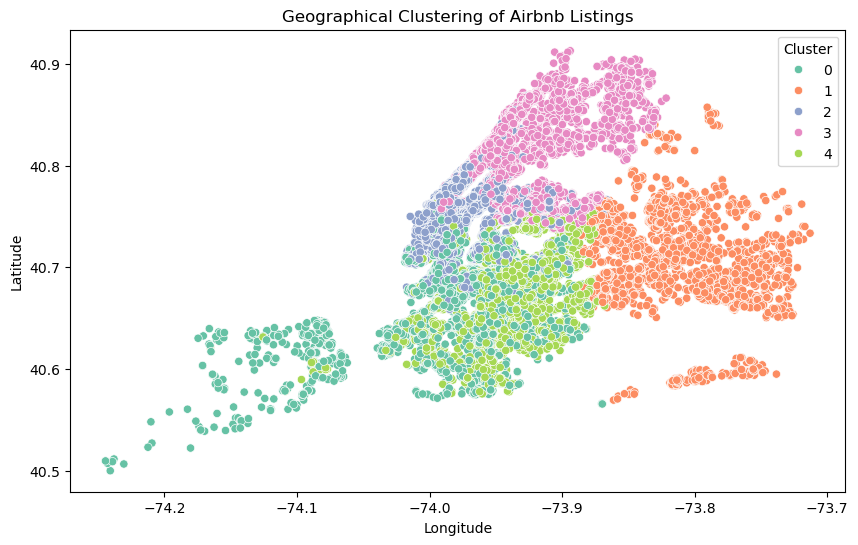

In [99]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_dataset,
    x='longitude',
    y='latitude',
    hue='Cluster',
    palette='Set2'
)

plt.title('Geographical Clustering of Airbnb Listings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

In [100]:
cluster_summary = df_dataset.groupby('Cluster')[
    ['price', 'latitude', 'longitude']
].mean()

cluster_summary

,price,latitude,longitude
Cluster,,,
0,4.751164,40.688298,-73.969765
1,4.340129,40.709152,-73.816690
2,5.258955,40.745578,-73.977138
3,4.368291,40.804502,-73.936412
4,4.009257,40.688472,-73.939570


The KMeans clustering analysis segmented Airbnb listings into geographically distinct groups based on latitude, longitude, and price.

The results reveal clear spatial pricing patterns across New York City. Some clusters represent premium high-price regions, while others correspond to more affordable residential or peripheral areas. In particular, one cluster displayed the highest average prices, suggesting the presence of central premium Airbnb zones.

The analysis demonstrates that geographical location plays a major role in determining Airbnb pricing behavior and highlights the usefulness of clustering techniques for identifying spatial market segments.

## Model 1

In [125]:
X = df_dataset.drop(columns=['price', 'Cluster'])

y = df_dataset['price']

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [127]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
y_pred_linear = linear_model.predict(X_test)

In [129]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = mean_squared_error(
    y_test,
    y_pred_linear
) ** 0.5

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
-------------------------
MAE: 0.29910355312378356
RMSE: 0.3823778627785275
R² Score: 0.5461258065877267


## Linear Regression

Linear Regression was used as a baseline regression model for predicting Airbnb listing prices. The model achieved an R² score of approximately 0.55, indicating moderate predictive performance.

The results suggest that linear models are limited in capturing the complex and nonlinear relationships present in Airbnb pricing data. Factors such as geographical location, room type, and listing characteristics likely interact in ways that are not fully represented by a simple linear relationship.

## Model 2

In [130]:
from sklearn.ensemble import RandomForestRegressor

In [131]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

In [132]:
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [133]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [134]:
best_rf = grid_search.best_estimator_

In [135]:
y_pred_rf = best_rf.predict(X_test)

In [136]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("----------------------")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
----------------------
MAE: 0.2583689363672983
RMSE: 0.33965242319428485
R² Score: 0.6418875317957562


## Tuned Random Forest Regressor

A Random Forest Regressor with hyperparameter tuning was implemented to improve predictive performance. GridSearchCV was used to optimize key parameters, including the number of trees and maximum tree depth.

The tuned Random Forest model achieved a substantial improvement over Linear Regression, reaching an R² score of approximately 0.64. This indicates that ensemble tree-based methods are more effective at capturing nonlinear relationships and feature interactions within the Airbnb dataset.

## Model 3

In [137]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [138]:
from xgboost import XGBRegressor

In [139]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [140]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [141]:
y_pred_xgb = xgb_model.predict(X_test)

In [142]:
mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = mean_squared_error(
    y_test,
    y_pred_xgb
) ** 0.5

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Results")
print("----------------")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R² Score:", r2_xgb)

XGBoost Results
----------------
MAE: 0.25870385951339414
RMSE: 0.3385952440735598
R² Score: 0.6441133356656554


## XGBoost Regressor

XGBoost was implemented as an advanced boosting-based regression model for Airbnb price prediction. The model achieved the highest predictive performance among the evaluated models, with an R² score of approximately 0.64.

The results demonstrate the effectiveness of gradient boosting techniques for structured tabular datasets. XGBoost was particularly successful in modeling complex pricing patterns influenced by location, room type, and listing characteristics.

In [144]:


results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest (Tuned)',
        'XGBoost'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_xgb
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf,
        rmse_xgb
    ],
    'R² Score': [
        r2_linear,
        r2_rf,
        r2_xgb
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.299104,0.382378,0.546126
1,Random Forest (Tuned),0.258369,0.339652,0.641888
2,XGBoost,0.258704,0.338595,0.644113


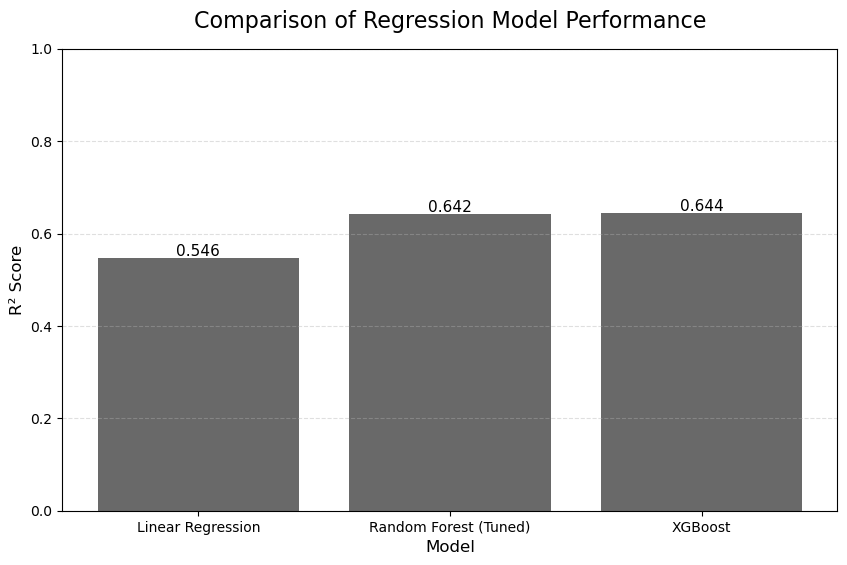

In [145]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    results['Model'],
    results['R² Score'],
    color='dimgray'
)

# Add value labels on top
for bar in bars:
    
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f'{height:.3f}',
        ha='center',
        fontsize=11
    )

plt.ylim(0, 1)

plt.title(
    'Comparison of Regression Model Performance',
    fontsize=16,
    pad=15
)

plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Final Model Selection

The ensemble-based models outperformed the Linear Regression model, indicating the presence of nonlinear relationships within the Airbnb pricing data.

Among the evaluated models, XGBoost achieved the highest predictive performance with an R² score of approximately 0.64. The tuned Random Forest model produced very similar results, demonstrating that ensemble tree-based methods are effective for capturing complex pricing patterns in Airbnb listings.

Although the models achieved moderate predictive accuracy, the results suggest that additional unobserved factors may influence Airbnb pricing behavior, including amenities, property quality, and detailed neighborhood characteristics.

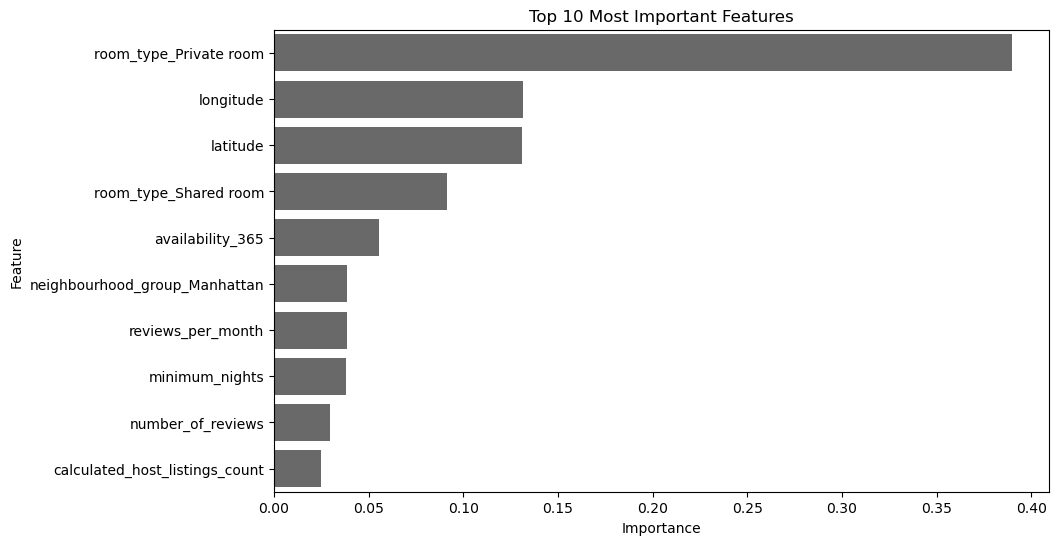

In [146]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature',
    color='dimgray'
)

plt.title('Top 10 Most Important Features')

plt.show()

# Feature Importance Analysis

The feature importance analysis revealed that room type was the strongest predictor of Airbnb listing prices. In particular, differences between private room listings and the baseline category of entire home/apartment listings had a substantial influence on predicted prices.

Geographical coordinates (latitude and longitude) were also among the most influential predictors, indicating that exact spatial location contributes more predictive information than broader neighborhood categories alone.

Additional variables such as availability, neighborhood group, and review activity contributed smaller but still meaningful effects to the predictive models.

# Model Export and Deployment Preparation

The final trained machine learning model was exported to allow future deployment and reuse without retraining. Saving trained models and preprocessing artifacts is an important step in practical machine learning workflows and MLOps pipelines.

In [152]:
import pickle

# Save final XGBoost model
with open("airbnb_xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save feature names
with open("airbnb_features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Deployment artifacts saved successfully.")

Deployment artifacts saved successfully.
